# CIFF habituating circuit

This notebook implements the concatenated incoherent feed-forward (CIFF) circuit from Eckert et al., *Biochemically plausible models of habituation for single-cell learning* (Current Biology, 2024).

Each variable is represented by an explicit inactive/active species pair whose total concentration is conserved at one.


In [1]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction, CatalyticMichaelisMenten


## Parameter Values


In [2]:
CIFF_Parameters = {
    'kIa1': 0.023, 'kIi1': 34.44,
    'kMa1': 17.7071, 'kMi1': 0.038241,
    'kRa1': 57.9236, 'kRi1': 1.39117, 'K1': 0.000534,
    'kIa2': 0.016011, 'kIi2': 14.3342,
    'kMa2': 4.33609, 'kMi2': 0.001471,
    'kRa2': 26.1702, 'kRi2': 45.9986, 'K2': 0.79082,
}

## Build the CIFF reaction network

Mass-action conversion represents every activation and unsaturated inactivation. `CatalyticMichaelisMenten` represents the two saturating response-inactivation reactions:

$$R_{j,a} \rightarrow R_{j,i}, \qquad v_j = k_{Ri,j}M_{j,a}\frac{R_{j,a}}{K_j + R_{j,a}}.$$


In [3]:
p = dict(CIFF_Parameters)

reactions = [
    # First incoherent feed-forward motif.
    MassAction(['I1_i'], ['I1_a'], input_channels=['S'],
               params=[p['kIa1']], params_controllability=[False]),
    MassAction(['I1_a'], ['I1_i'], input_channels=[None],
               params=[p['kIi1']], params_controllability=[False]),
    MassAction(['I1_a', 'M1_i'], ['I1_a', 'M1_a'], input_channels=[None],
               params=[p['kMa1']], params_controllability=[False]),
    MassAction(['M1_a'], ['M1_i'], input_channels=[None],
               params=[p['kMi1']], params_controllability=[False]),
    MassAction(['I1_a', 'R1_i'], ['I1_a', 'R1_a'], input_channels=[None],
               params=[p['kRa1']], params_controllability=[False]),
    CatalyticMichaelisMenten(['R1_a'], ['R1_i'], ['M1_a'],
                              params=[p['kRi1'], p['K1']],
                              params_controllability=[False, False]),

    # Second motif, driven by active R1.
    MassAction(['R1_a', 'I2_i'], ['R1_a', 'I2_a'], input_channels=[None],
               params=[p['kIa2']], params_controllability=[False]),
    MassAction(['I2_a'], ['I2_i'], input_channels=[None],
               params=[p['kIi2']], params_controllability=[False]),
    MassAction(['I2_a', 'M2_i'], ['I2_a', 'M2_a'], input_channels=[None],
               params=[p['kMa2']], params_controllability=[False]),
    MassAction(['M2_a'], ['M2_i'], input_channels=[None],
               params=[p['kMi2']], params_controllability=[False]),
    MassAction(['I2_a', 'R2_i'], ['I2_a', 'R2_a'], input_channels=[None],
               params=[p['kRa2']], params_controllability=[False]),
    CatalyticMichaelisMenten(['R2_a'], ['R2_i'], ['M2_a'],
                              params=[p['kRi2'], p['K2']],
                              params_controllability=[False, False]),
]

ciff = IOCRN(reactions, output_labels=['R2_a'], solver='LSODA', atol=1e-9, rtol=1e-7)
ciff.compile()
print(ciff)


Inputs: ['S'] 
Species: ['I1_a', 'I1_i', 'I2_a', 'I2_i', 'M1_a', 'M1_i', 'M2_a', 'M2_i', 'R1_a', 'R1_i', 'R2_a', 'R2_i'] 
Output Species: ['R2_a'] 
I1_i ----> I1_a;  [MAK(0.023, S)]
I1_a ----> I1_i;  [MAK(34.44)]
I1_a + M1_i ----> I1_a + M1_a;  [MAK(17.7071)]
M1_a ----> M1_i;  [MAK(0.038241)]
I1_a + R1_i ----> I1_a + R1_a;  [MAK(57.9236)]
R1_a ----> R1_i;  [CatalyticMM(E=M1_a, k=1.39117, K=0.000534)]
I2_i + R1_a ----> I2_a + R1_a;  [MAK(0.016011)]
I2_a ----> I2_i;  [MAK(14.3342)]
I2_a + M2_i ----> I2_a + M2_a;  [MAK(4.33609)]
M2_a ----> M2_i;  [MAK(0.001471)]
I2_a + R2_i ----> I2_a + R2_a;  [MAK(26.1702)]
R2_a ----> R2_i;  [CatalyticMM(E=M2_a, k=45.9986, K=0.79082)]


## Initial Conditions

In [4]:
def inactive_initial_condition(crn):
    x0 = np.zeros(crn.num_species)
    for label in ['I1_i', 'M1_i', 'R1_i', 'I2_i', 'M2_i', 'R2_i']:
        x0[crn.species_label_to_idx(label)] = 1.0
    return x0

x0 = inactive_initial_condition(ciff)
print(x0)

[0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.]


## Input Signal

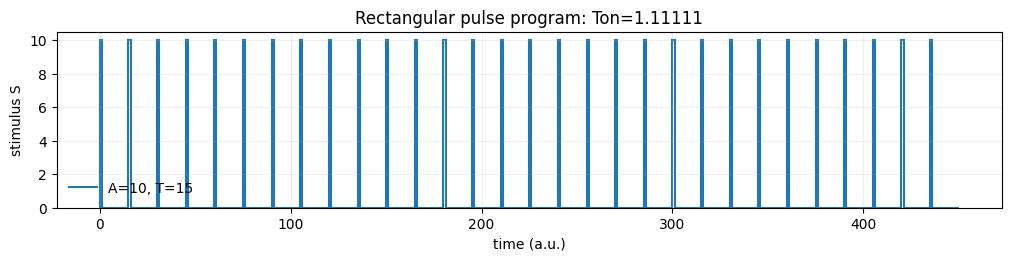

In [5]:
def rectangular_pulse_program(A, T, Ton, n_pulses, points_per_time=100):
    on_grid = np.linspace(0.0, Ton, max(3, int(np.ceil(Ton * points_per_time)) + 1))
    off_grid = np.linspace(0.0, T - Ton, max(3, int(np.ceil((T - Ton) * points_per_time)) + 1))
    inputs, segments = [], []
    for _ in range(n_pulses):
        inputs.extend([np.asarray([A]), np.asarray([0.0])])
        segments.extend([on_grid, off_grid])
    return [inputs], segments

def pulse_conditions(A, T):
    A_values = np.atleast_1d(A).astype(float)
    T_values = np.atleast_1d(T).astype(float)
    if len(A_values) == 1:
        A_values = np.repeat(A_values, len(T_values))
    if len(T_values) == 1:
        T_values = np.repeat(T_values, len(A_values))
    if len(A_values) != len(T_values):
        raise ValueError('A and T must be scalars, equal-length lists, or one scalar and one list.')
    return list(zip(A_values, T_values))


A, T, Ton, n_pulses = 10.0, 15.0, 1.1111111111111112, 30  # A and T may also be lists
fig, ax = plt.subplots(figsize=(10, 2.5), constrained_layout=True)
for A_value, T_value in pulse_conditions(A, T):
    signal_edges = np.empty(2 * n_pulses + 1)
    signal_values = np.empty(2 * n_pulses)
    for pulse_idx in range(n_pulses):
        signal_edges[2 * pulse_idx] = pulse_idx * T_value
        signal_edges[2 * pulse_idx + 1] = pulse_idx * T_value + Ton
        signal_edges[2 * pulse_idx + 2] = (pulse_idx + 1) * T_value
        signal_values[2 * pulse_idx] = A_value
        signal_values[2 * pulse_idx + 1] = 0.0
    ax.stairs(signal_values, signal_edges, linewidth=1.5, label=f'A={A_value:g}, T={T_value:g}')
ax.set_xlabel('time (a.u.)')
ax.set_ylabel('stimulus S')
ax.set_title(f'Rectangular pulse program: Ton={Ton:g}')
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.show()

## Simulate the pulse protocol


In [6]:
A, T, Ton, n_pulses = 10.0, [25, 20, 15], 1.1111111111111112, 50  # A and T may also be lists
simulation_results = []
for A_value, T_value in pulse_conditions(A, T):
    u_program, time_segments = rectangular_pulse_program(A_value, T_value, Ton, n_pulses)
    time, trajectories, outputs, _ = ciff.transient_response_piecewise(
        u_nested_list=u_program,
        x0_list=[x0],
        nested_time_horizon=time_segments,
        force=True,
    )
    simulation_results.append((A_value, T_value, time, trajectories[0], outputs[0][0]))

## Habituation time

For response peaks $p_i$, the paper defines the habituation time $h_t=i$ at the first consecutive pair satisfying $(p_i-p_{i+1})/p_i < 0.01$. The time is measured in number of stimuli, not absolute time.


In [7]:
def paper_habituation_time(time, response, T, n_pulses, tolerance=0.01):
    peaks = np.asarray([
        response[(time >= pulse_idx * T) & (time <= (pulse_idx + 1) * T)].max()
        for pulse_idx in range(n_pulses)
    ])
    relative_decrements = (peaks[:-1] - peaks[1:]) / peaks[:-1]
    qualifying_indices = np.flatnonzero(relative_decrements < tolerance)
    habituation_time = int(qualifying_indices[0] + 1) if len(qualifying_indices) else np.inf
    return habituation_time, peaks


habituation_results = []
for A_value, T_value, time, x, response in simulation_results:
    habituation_time, response_peaks = paper_habituation_time(
        time, response, T_value, n_pulses
    )
    habituation_results.append({
        'A': A_value,
        'T': T_value,
        'habituation_time': habituation_time,
        'response_peaks': response_peaks,
    })

pd.DataFrame(habituation_results).drop(columns='response_peaks')

,A,T,habituation_time
0,10.0,25.0,25
1,10.0,20.0,22
2,10.0,15.0,14


## Recovery time

After habituation, stimulation is stopped and a single test stimulus with the same `A` and `Ton` is applied. Recovery time is the minimum unstimulated gap for which the test-response peak is within 5% of the first response peak. The minimum gap is found by binary search.


In [8]:
def compute_recovery_time(iocrn, A, T, Ton, habituation_time, x0,
                        recovery_tolerance=0.05, max_gap=4000.0, search_depth=16):
    # Match the paper code: each training period ends at its final 0.01-spaced sample,
    # and recovery starts from the sampled state at h_t * T - 0.01.
    points_per_time = 100
    train_pulses = int(habituation_time)
    on_steps = int(Ton * points_per_time)
    period_steps = int(T * points_per_time)
    on_grid = np.arange(on_steps + 1) / points_per_time
    off_grid = np.arange(period_steps - on_steps) / points_per_time
    train_inputs = [[value for _ in range(train_pulses)
                     for value in (np.asarray([A]), np.asarray([0.0]))]]
    train_segments = [grid for _ in range(train_pulses) for grid in (on_grid, off_grid)]
    _, train_trajectories, train_outputs, _ = iocrn.transient_response_piecewise(
        u_nested_list=train_inputs,
        x0_list=[x0],
        nested_time_horizon=train_segments,
        force=True,
    )
    habituated_state = train_trajectories[0][:, -1]
    first_period_samples = len(on_grid) + len(off_grid)
    first_peak = train_outputs[0][0, :first_period_samples].max()

    test_inputs, test_segments = rectangular_pulse_program(A, T, Ton, 1)

    def probe(gap):
        gap_grid = np.asarray([0.0, float(gap)])
        inputs = [[np.asarray([0.0])] + test_inputs[0]]
        segments = [gap_grid] + test_segments
        time, _, outputs, _ = iocrn.transient_response_piecewise(
            u_nested_list=inputs,
            x0_list=[habituated_state],
            nested_time_horizon=segments,
            force=True,
        )
        test_peak = outputs[0][0][time >= gap].max()
        relative_difference = abs(test_peak - first_peak) / max(abs(first_peak), 1e-12)
        return relative_difference <= recovery_tolerance, relative_difference, test_peak

    recovered, relative_difference, test_peak = probe(max_gap)
    if not recovered:
        return np.inf, relative_difference, test_peak

    low, high = 0.0, float(max_gap)
    best = (high, relative_difference, test_peak)
    for _ in range(search_depth):
        midpoint = 0.5 * (low + high)
        recovered, relative_difference, test_peak = probe(midpoint)
        if recovered:
            high = midpoint
            best = (high, relative_difference, test_peak)
        else:
            low = midpoint
    return best


paper_recovery_times = {25.0: 2063.0, 20.0: 1914.0, 15.0: 1549.0}

for result in habituation_results:
    recovery_time, recovery_difference, recovery_peak = compute_recovery_time(
        ciff, result['A'], result['T'], Ton, result['habituation_time'], x0,
    )
    result['recovery_time'] = recovery_time
    result['paper_recovery_time'] = paper_recovery_times.get(float(result['T']), np.nan)
    result['recovery_difference'] = recovery_difference
    result['recovery_peak'] = recovery_peak

pd.DataFrame(habituation_results).drop(columns=['response_peaks', 'recovery_peak'])

,A,T,habituation_time,recovery_time,paper_recovery_time,recovery_difference
0,10.0,25.0,25,2062.683105,2063.0,0.049999
1,10.0,20.0,22,1914.123535,1914.0,0.049998
2,10.0,15.0,14,1548.828125,1549.0,0.049999


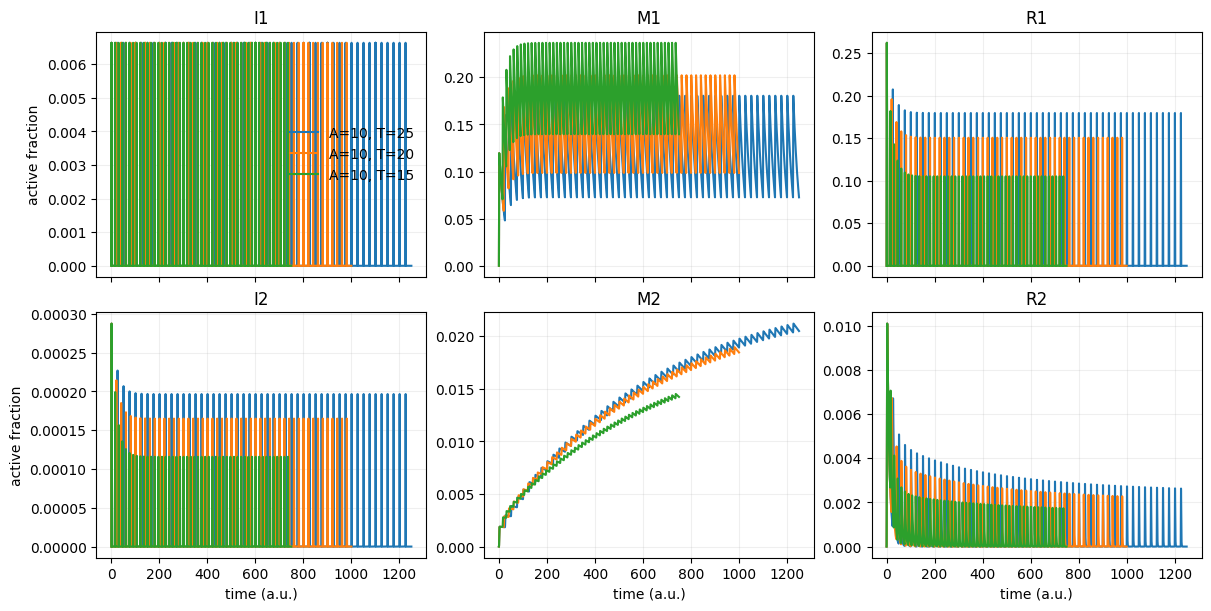

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, constrained_layout=True)
species_grid = [['I1_a', 'M1_a', 'R1_a'], ['I2_a', 'M2_a', 'R2_a']]

for row_idx, row in enumerate(species_grid):
    for col_idx, species in enumerate(row):
        ax = axes[row_idx, col_idx]
        for A_value, T_value, time, x, response in simulation_results:
            ax.plot(time, x[ciff.species_label_to_idx(species)], linewidth=1.5,
                    label=f'A={A_value:g}, T={T_value:g}')
        ax.set_title(species.replace('_a', ''))
        ax.grid(alpha=0.2)
        if col_idx == 0:
            ax.set_ylabel('active fraction')
        if row_idx == 1:
            ax.set_xlabel('time (a.u.)')
        if row_idx == 0 and col_idx == 0:
            ax.legend(frameon=False)

plt.show()